# 00 · Conocer los datos antes de preguntar

Objetivo: entender los datos antes de construir el agente. Responderemos qué contiene el corpus, qué fuente sirve para cada pregunta y qué límites tiene.

Trabajamos solo con los 12 informes 10-K locales: seis empresas y FY2024–FY2025. No usamos internet ni API. Lee cada visual como una decisión práctica para el agente, no como un adorno.  
**Requisitos que prepara:** R10, R13 y R14 · [Guía de datos](../docs/02_datos_corpus_y_xbrl.md)

In [1]:
# Arranque común: funciona desde la raíz o desde notebooks/
import sys
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
if str(RAIZ / "src") not in sys.path:
    sys.path.insert(0, str(RAIZ / "src"))

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
from IPython.display import display

from agente10k import datos

COLORES = {"1A": "#D95F59", "7": "#4C78A8", "7A": "#8F63B8", "8": "#59A14F"}
plt.rcParams.update({"figure.dpi": 115, "axes.titleweight": "bold", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

## 1. ¿Está listo el entorno?

**Objetivo.** Comprobar que todos ejecutamos el mismo entorno. La celda compara las versiones instaladas con las fijadas en `requirements.txt`.

**Cómo leerlo.** Cada fila debe terminar en ✓. Si aparece ⚠, instala de nuevo las dependencias antes de continuar: una versión distinta puede cambiar resultados o romper el notebook.

**Conclusión.** Un resultado reproducible empieza por un entorno reproducible.

In [2]:
lineas = (RAIZ / "requirements.txt").read_text(encoding="utf-8").splitlines()
fijadas = [linea.strip().split("==", 1) for linea in lineas
           if "==" in linea and not linea.lstrip().startswith("#")]

filas = []
for paquete, esperada in fijadas:
    try:
        instalada = version(paquete)
    except PackageNotFoundError:
        instalada = "no instalado"
    filas.append({"Paquete": paquete, "Esperada": esperada,
                  "Instalada": instalada, "Estado": "✓" if instalada == esperada else "⚠"})

versiones = pd.DataFrame(filas)
display(versiones.style.hide(axis="index").set_properties(**{"text-align": "left"}))
assert (versiones["Estado"] == "✓").all(), 'El entorno no coincide con requirements.txt'

Paquete,Esperada,Instalada,Estado
langchain,1.3.18,1.3.18,✓
langchain-core,1.6.1,1.6.1,✓
langgraph,1.2.11,1.2.11,✓
langchain-openrouter,0.2.8,0.2.8,✓
langchain-huggingface,1.2.2,1.2.2,✓
sentence-transformers,6.0.1,6.0.1,✓
faiss-cpu,1.15.0,1.15.0,✓
rank-bm25,0.2.2,0.2.2,✓
pandas,2.3.3,2.3.3,✓
pyarrow,23.0.0,23.0.0,✓


## 2. ¿Podemos confiar en los archivos?

**Objetivo.** Verificar que el corpus y el índice recibidos no han cambiado. SHA-256 es una huella digital: un solo byte distinto cambia la huella.

**Qué hace la celda.** Valida los archivos, sus hashes y que las 1.749 filas de metadatos siguen alineadas con los vectores del índice. Después carga secciones, fragmentos y hechos XBRL.

**Cómo leerlo.** Las cuatro tarjetas resumen el tamaño útil: 12 informes, 48 secciones, 1.749 fragmentos y 135 cifras. Si falla aquí, no se debe buscar ni responder.

**Conclusión.** Los datos son la fuente de verdad; primero se validan y luego se usan.

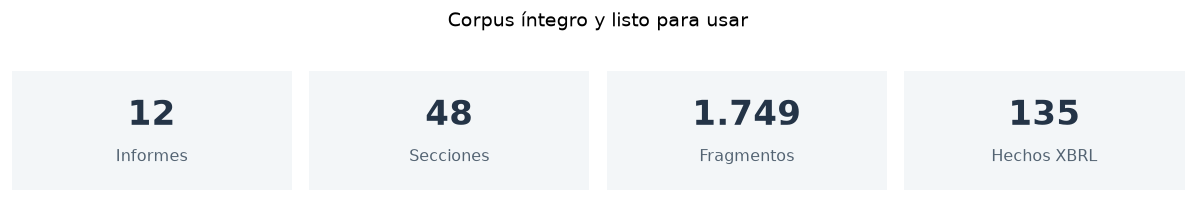

In [3]:
datos.verificar_corpus()
secciones = datos.cargar_secciones()
chunks = datos.cargar_chunks()
xbrl = datos.cargar_xbrl()

indicadores = [
    ("Informes", secciones[["ticker", "fiscal_year"]].drop_duplicates().shape[0]),
    ("Secciones", len(secciones)),
    ("Fragmentos", len(chunks)),
    ("Hechos XBRL", len(xbrl)),
]

fig, ejes = plt.subplots(1, 4, figsize=(10.5, 1.65))
for eje, (nombre, valor) in zip(ejes, indicadores):
    eje.set_facecolor("#F3F6F8")
    eje.text(0.5, 0.62, f"{valor:,}".replace(",", "."), ha="center", va="center",
             fontsize=21, fontweight="bold", color="#243447")
    eje.text(0.5, 0.24, nombre, ha="center", color="#536372")
    eje.set_xticks([]); eje.set_yticks([])
    for borde in eje.spines.values(): borde.set_visible(False)
fig.suptitle("Corpus íntegro y listo para usar", y=1.03)
plt.tight_layout()
plt.show()

## 3. Tres vistas, tres trabajos

**Objetivo.** Separar las tres formas de mirar el mismo informe.

- **Sección completa:** da contexto amplio, pero puede ser enorme.
- **Fragmento:** permite localizar una explicación concreta sin leerlo todo.
- **XBRL:** guarda las cifras exactas reportadas por la empresa.

**Cómo leer el diagrama.** Las flechas muestran que una sección se divide en fragmentos para buscar; XBRL es una vía aparte para números.

**Conclusión.** No hay una fuente “mejor” para todo: texto para explicar, XBRL para cuantificar.

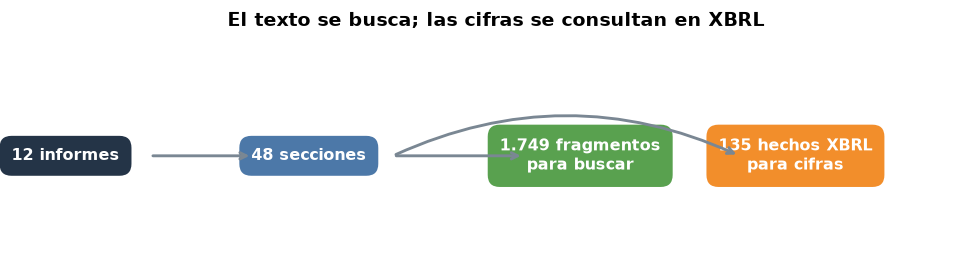

In [4]:
fig, ax = plt.subplots(figsize=(10.5, 2.5))
ax.axis("off")
cajas = [(0.04, "12 informes", "#243447"), (0.30, "48 secciones", "#4C78A8"),
         (0.59, "1.749 fragmentos\npara buscar", "#59A14F"),
         (0.82, "135 hechos XBRL\npara cifras", "#F28E2B")]
for x0, texto, color in cajas:
    ax.text(x0, 0.5, texto, transform=ax.transAxes, ha="center", va="center", color="white",
            fontweight="bold", bbox={"boxstyle": "round,pad=0.75", "fc": color, "ec": "none"})
ax.annotate("", xy=(0.24, .5), xytext=(.13, .5), xycoords="axes fraction",
            arrowprops={"arrowstyle": "->", "color": "#7A8793", "lw": 1.8})
ax.annotate("", xy=(0.53, .5), xytext=(.39, .5), xycoords="axes fraction",
            arrowprops={"arrowstyle": "->", "color": "#7A8793", "lw": 1.8})
ax.annotate("", xy=(0.76, .5), xytext=(.39, .5), xycoords="axes fraction",
            arrowprops={"arrowstyle": "->", "color": "#7A8793", "lw": 1.8,
                        "connectionstyle": "arc3,rad=-0.23"})
ax.set_title("El texto se busca; las cifras se consultan en XBRL", pad=12)
plt.show()

## 4. Leerlo todo sale caro

**Objetivo.** Ver por qué no conviene enviar un 10-K entero al modelo. Un token es una pequeña pieza de texto: más tokens implican más coste y más espera.

**Datos y lectura.** Cada casilla representa los tokens de un item para una empresa y ejercicio; los tonos más oscuros y los valores mayores son secciones más caras de leer completas.

**Conclusión.** Primero se busca un fragmento pequeño; la sección completa queda como último recurso.

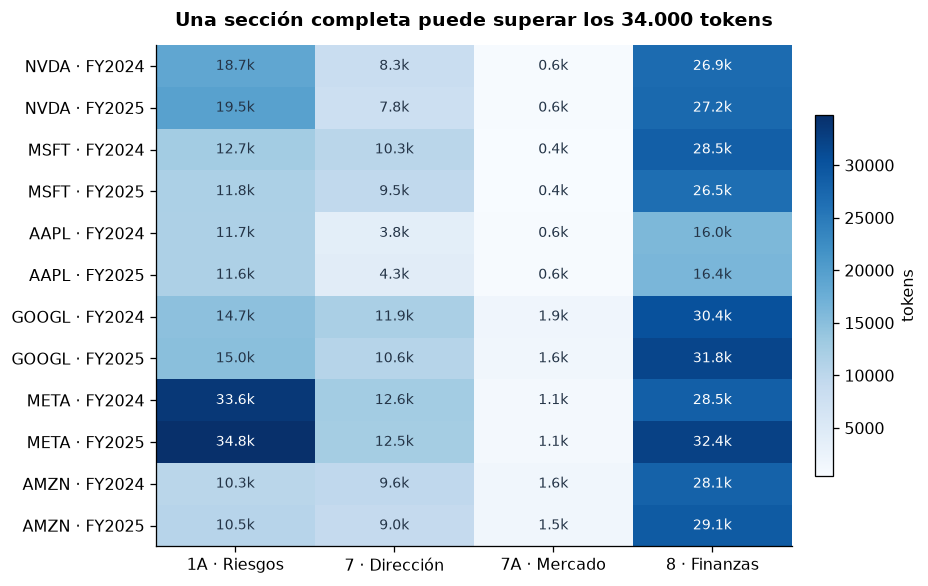

Máximo: META FY2025 · Item 1A · 34.751 tokens


In [5]:
orden_empresas = ["NVDA", "MSFT", "AAPL", "GOOGL", "META", "AMZN"]
orden_filas = pd.MultiIndex.from_product([orden_empresas, [2024, 2025]])
tokens = (secciones.pivot_table(index=["ticker", "fiscal_year"], columns="item",
                                values="n_tokens", aggfunc="sum")
          .reindex(index=orden_filas, columns=["1A", "7", "7A", "8"]))

fig, ax = plt.subplots(figsize=(8.3, 5.2))
imagen = ax.imshow(tokens.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(4), ["1A · Riesgos", "7 · Dirección", "7A · Mercado", "8 · Finanzas"])
ax.set_yticks(range(len(tokens)), [f"{t} · FY{fy}" for t, fy in tokens.index])
for i in range(tokens.shape[0]):
    for j in range(tokens.shape[1]):
        valor = int(tokens.iloc[i, j])
        ax.text(j, i, f"{valor / 1000:.1f}k", ha="center", va="center",
                color="white" if valor > 20_000 else "#243447", fontsize=9)
ax.set_title("Una sección completa puede superar los 34.000 tokens", pad=12)
barra = fig.colorbar(imagen, ax=ax, shrink=.72, pad=.03)
barra.set_label("tokens")
plt.tight_layout()
plt.show()

mayor = secciones.loc[secciones["n_tokens"].idxmax()]
print(f"Máximo: {mayor['ticker']} FY{mayor['fiscal_year']} · Item {mayor['item']} · {mayor['n_tokens']:,} tokens".replace(",", "."))

**Objetivo.** Entender dónde está el texto y dónde aparecen tablas.

**Datos y lectura.** Cada barra suma fragmentos de los 12 informes; verde es texto normal y rojo marca fragmentos con tablas. Item 8 concentra más material financiero y muchas tablas.

**Conclusión.** Una tabla partida puede ser útil como contexto, pero una cifra se confirma siempre en XBRL.

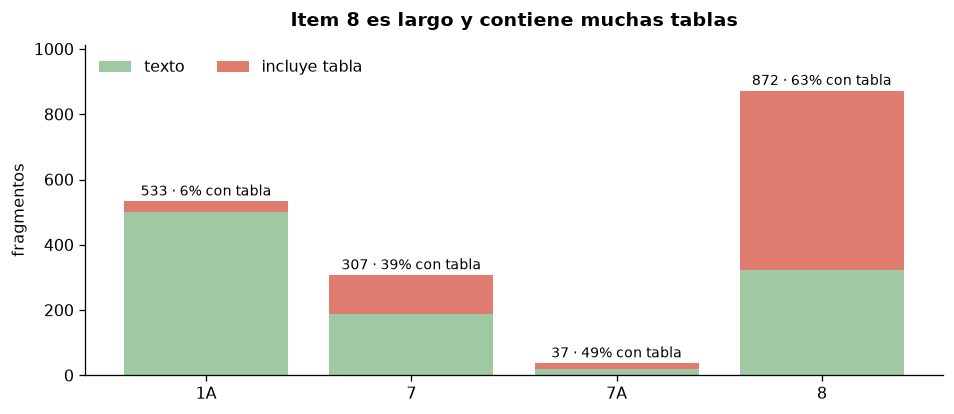

Regla práctica: una cifra de una tabla partida se confirma en XBRL, no en el fragmento.


In [6]:
resumen_chunks = (chunks.groupby("item")
                  .agg(total=("chunk_id", "size"), con_tabla=("contiene_tabla", "sum"))
                  .reindex(["1A", "7", "7A", "8"]))
resumen_chunks["sin_tabla"] = resumen_chunks["total"] - resumen_chunks["con_tabla"]

fig, ax = plt.subplots(figsize=(8.4, 3.7))
xpos = np.arange(len(resumen_chunks))
ax.bar(xpos, resumen_chunks["sin_tabla"], color="#9EC9A3", label="texto")
ax.bar(xpos, resumen_chunks["con_tabla"], bottom=resumen_chunks["sin_tabla"],
       color="#E07B70", label="incluye tabla")
for i, fila in enumerate(resumen_chunks.itertuples()):
    porcentaje = 100 * fila.con_tabla / fila.total
    ax.text(i, fila.total + 18, f"{fila.total} · {porcentaje:.0f}% con tabla", ha="center", fontsize=9)
ax.set_xticks(xpos, ["1A", "7", "7A", "8"])
ax.set_ylabel("fragmentos")
ax.set_ylim(0, resumen_chunks["total"].max() * 1.16)
ax.legend(frameon=False, ncol=2)
ax.set_title("Item 8 es largo y contiene muchas tablas", pad=12)
plt.tight_layout()
plt.show()

print("Regla práctica: una cifra de una tabla partida se confirma en XBRL, no en el fragmento.")

## 5. FY2025 no siempre termina en diciembre

**Objetivo.** Evitar confundir el ejercicio fiscal con el año de publicación. `fiscal_year` es la etiqueta del ejercicio de cada empresa.

**Datos y lectura.** Cada punto sitúa el mes de cierre de FY2025. NVIDIA cierra en enero, Microsoft en junio, Apple en septiembre y las demás en diciembre.

**Conclusión.** En una pregunta debemos escribir “FY2025”, no asumir que el informe se presentó en 2025.

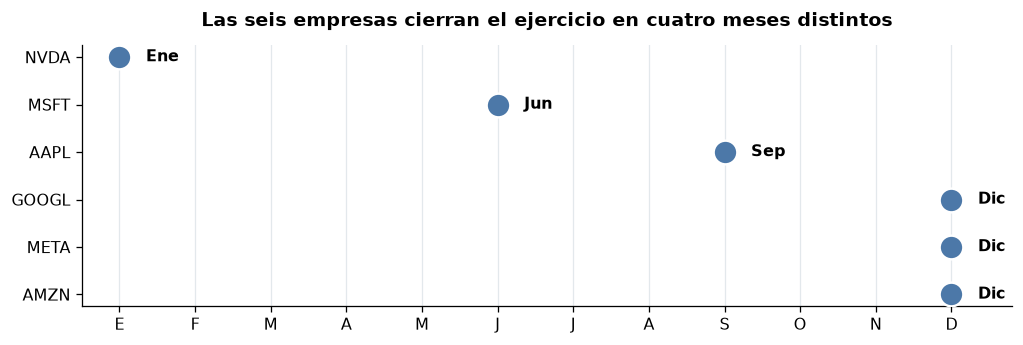

Ejemplo: GOOGL FY2025 cerró el 31-12-2025 y su 10-K se presentó en 2026.


In [7]:
cierres = xbrl.assign(period_end=pd.to_datetime(xbrl["period_end"]))
cierres = (cierres[["ticker", "fiscal_year", "period_end"]].drop_duplicates()
           .sort_values(["ticker", "fiscal_year"]))
meses = cierres.groupby("ticker")["period_end"].first().dt.month.reindex(orden_empresas)
nombres_mes = {1: "Ene", 6: "Jun", 9: "Sep", 12: "Dic"}

fig, ax = plt.subplots(figsize=(9, 3.1))
for i, (ticker, mes) in enumerate(meses.items()):
    ax.scatter(mes, i, s=220, color="#4C78A8", edgecolor="white", linewidth=1.5, zorder=3)
    ax.text(mes + .35, i, nombres_mes[mes], va="center", fontweight="bold")
ax.set_yticks(range(len(meses)), meses.index)
ax.set_xticks(range(1, 13), ["E", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_xlim(.5, 12.8); ax.grid(axis="x", color="#E3E8EC")
ax.invert_yaxis()
ax.set_title("Las seis empresas cierran el ejercicio en cuatro meses distintos", pad=12)
plt.tight_layout()
plt.show()

print("Ejemplo: GOOGL FY2025 cerró el 31-12-2025 y su 10-K se presentó en 2026.")

## 6. ¿Qué cifras existen de verdad?

**Objetivo.** Distinguir una cifra disponible de un dato realmente ausente.

**Datos y lectura.** Filas = conceptos financieros; columnas = empresa y ejercicio. Verde significa “reportado en XBRL”. Gris significa “no aparece con ese concepto”; **no significa cero**.

Hay 21 celdas grises: **10 son huecos reales** y 11 usan la otra etiqueta de ingresos.

**Conclusión.** Antes de responder “no existe”, hay que comprobar los dos conceptos posibles de ingresos; si sigue ausente, se declara el hueco sin estimar.

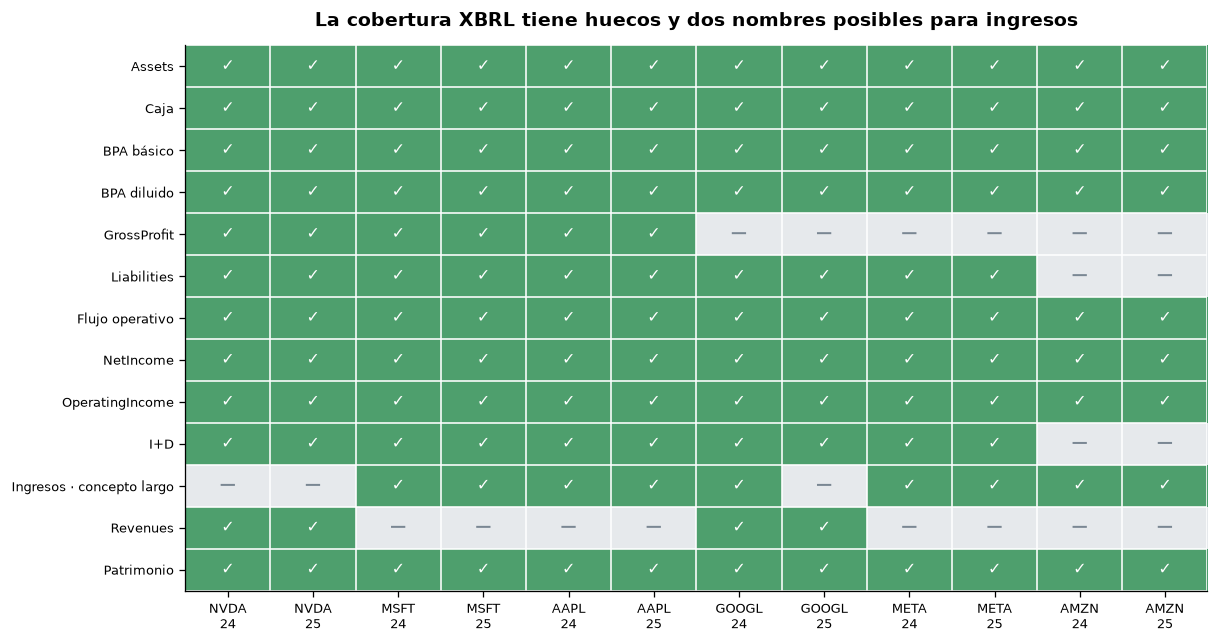

135 hechos disponibles · 21 celdas grises: 10 huecos reales y 11 etiquetas alternativas de ingresos.


In [8]:
columnas = pd.MultiIndex.from_product([orden_empresas, [2024, 2025]])
conceptos = sorted(xbrl["concept"].unique())
cobertura = (xbrl.assign(disponible=1)
             .pivot_table(index="concept", columns=["ticker", "fiscal_year"],
                          values="disponible", fill_value=0)
             .reindex(index=conceptos, columns=columnas, fill_value=0))

etiquetas = {
    "CashAndCashEquivalentsAtCarryingValue": "Caja",
    "EarningsPerShareBasic": "BPA básico",
    "EarningsPerShareDiluted": "BPA diluido",
    "NetCashProvidedByUsedInOperatingActivities": "Flujo operativo",
    "ResearchAndDevelopmentExpense": "I+D",
    "RevenueFromContractWithCustomerExcludingAssessedTax": "Ingresos · concepto largo",
    "StockholdersEquity": "Patrimonio",
}

fig, ax = plt.subplots(figsize=(10.7, 5.7))
ax.imshow(cobertura.values, cmap=ListedColormap(["#E6E9EC", "#4E9F6D"]), vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(columnas)), [f"{t}\n{str(fy)[-2:]}" for t, fy in columnas], fontsize=8)
ax.set_yticks(range(len(conceptos)), [etiquetas.get(c, c.replace("Loss", "")) for c in conceptos], fontsize=8)
for i in range(cobertura.shape[0]):
    for j in range(cobertura.shape[1]):
        ax.text(j, i, "✓" if cobertura.iloc[i, j] else "—", ha="center", va="center",
                color="white" if cobertura.iloc[i, j] else "#7A8793", fontweight="bold")
ax.set_xticks(np.arange(-.5, cobertura.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, cobertura.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)
ax.set_title("La cobertura XBRL tiene huecos y dos nombres posibles para ingresos", pad=12)
plt.tight_layout()
plt.show()

ausencias = cobertura.size - int(cobertura.to_numpy().sum())
print(f"{len(xbrl)} hechos disponibles · {ausencias} celdas grises: 10 huecos reales y 11 etiquetas alternativas de ingresos.")

## 7. Cuatro trampas que cambian la respuesta

1. **Ingresos no tiene un nombre universal.** NVDA usa `Revenues`; AAPL, MSFT, META y AMZN usan el concepto largo. GOOGL usa ambos en FY2024 y sólo `Revenues` en FY2025.
2. **Hay 10 huecos reales.** Gross profit falta para AMZN, GOOGL y META; liabilities e I+D faltan para AMZN, en ambos ejercicios.
3. **El BPA de NVDA necesita contexto.** Bajó tras un split 10:1 aunque el beneficio neto aumentó.
4. **Excepción documental.** Para NVDA, el contenido que usamos como Item 8 procede del Item 15 original.

**Qué hace la celda siguiente.** Convierte estas cuatro advertencias en comprobaciones pequeñas sobre los datos reales. Si un `assert` falla, el supuesto ya no es válido.

**Conclusión.** Estas reglas evitan respuestas plausibles pero erróneas: especialmente con ingresos, BPA y NVIDIA.

In [9]:
# Tres comprobaciones pequeñas; la batería completa vive en tests/test_datos.py
assert (len(secciones), len(chunks), len(xbrl)) == (48, 1749, 135)

excepciones = secciones.loc[secciones["item"].ne(secciones["item_origen"]),
                            ["ticker", "fiscal_year", "item", "item_origen"]]
bpa_nvda = (xbrl.query("ticker == 'NVDA' and concept == 'EarningsPerShareBasic'")
            .set_index("fiscal_year")["value"])

conceptos_con_huecos_reales = ["GrossProfit", "Liabilities", "ResearchAndDevelopmentExpense"]
universo = pd.MultiIndex.from_product(
    [orden_empresas, [2024, 2025], conceptos_con_huecos_reales],
    names=["ticker", "fiscal_year", "concept"],
)
reportados = pd.MultiIndex.from_frame(xbrl[["ticker", "fiscal_year", "concept"]])
huecos_reales = len(universo.difference(reportados))

assert len(excepciones) == 2 and set(excepciones["item_origen"]) == {"15"}
assert huecos_reales == 10
assert bpa_nvda.loc[2024] == 12.05 and bpa_nvda.loc[2025] == 2.97
print("✓ Conteos, excepción de NVDA, huecos y precisión del BPA comprobados.")

✓ Conteos, excepción de NVDA, huecos y precisión del BPA comprobados.


## En una frase

**XBRL para cifras exactas, fragmentos para buscar explicaciones y secciones completas sólo cuando hagan falta.**

Ya sabemos qué hay, cuánto cuesta y qué no debemos asumir. Si un dato no está, se dice: no se estima. El siguiente paso convierte estas tres vías en herramientas: [01 · Herramientas](01_herramientas.ipynb).